In [2]:
# import libraries
import numpy as np
import pickle
import matplotlib.pyplot as plt
from adjustText import adjust_text
from utils import reorder_transition_matrix, infinitesimal_generator
from utils_interaction_chain_viz import visualize_heatmap, labels_and_sizes_same

In [ ]:
def load_and_visualize_heatmap(path, suptitle="", cbar_label=r'$Log_{10} (Pr[i \to j])$ over 100 ns', transform_transition_dt=-1, log_10=False, remove_fgs=[], dpi=300):

    with open(path, "rb") as f:
        tm, states = pickle.load(f)

    with open(f"data/anchor_coordinates.pickle", "rb") as f:
        anchor_coordinates = pickle.load(f)
        
    # Sort anchor coordinates by Z
    anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
    
    # Remove FGs
    # for key in list(anchor_coordinates.keys()):
    #     for prefix in remove_fgs:
    #         if key.startswith(prefix):
    #             del anchor_coordinates[key]
    #             break
    
    for key in list(anchor_coordinates.keys()):
        if key not in states:
            states.append(key)
            tm = np.vstack([tm, np.zeros(tm.shape[1])])
            tm = np.hstack([tm, np.zeros((tm.shape[0], 1))])
    
    
    new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
    tm = reorder_transition_matrix(tm, states, new_states)
    if transform_transition_dt != -1: tm = infinitesimal_generator(tm, dt=transform_transition_dt)
    if log_10: tm = np.log10(tm)

    first_and_last_factor = 20
    # labels, label_sizes = labels_and_sizes(new_states, first_and_last_factor=first_and_last_factor)
    labels, label_sizes = labels_and_sizes_same(first_and_last_factor=first_and_last_factor)
    visualize_heatmap(tm,
                    suptitle=suptitle,
                    title="",
                    labels=labels,
                    label_sizes=label_sizes,
                    cbar_label=cbar_label,
                    first_and_last_factor=first_and_last_factor,
                    dpi=dpi)
    return tm
    

In [ ]:
for step in [1, 2, 4, 8, 16, 32, 64]:
    load_and_visualize_heatmap(f"data/transition_matrices/interactions-150-180-symmetric-{100*step}ns.pickle",
                               suptitle=f"Interaction transition matrix, 150-180ns, 50 sims",
                               cbar_label=r'$Log_{10} (Pr[i \to j])$ over ' + str(step * 100) + " ns",
                               log_10=True)

In [ ]:
for step in [1, 2, 4, 8, 16]: #, 32, 64]: # above 16 doesn't work
    load_and_visualize_heatmap(f"data/transition_matrices/interactions-150-180-symmetric-{100*step}ns.pickle",
                               suptitle=f"Transition rate matrix, 150-180ns, 50 sims, calculated from transition matrix {step * 100} ns steps",
                               cbar_label=r'$\frac{1}{ns}$', # todo not log10?
                               transform_transition_dt=step * 100)

In [1]:
for step in [1, 2, 4, 8, 16]: #, 32, 64]: # above 16 doesn't work
    load_and_visualize_heatmap(f"data/transition_matrices/interactions-150-180-symmetric-{100*step}ns.pickle",
                               suptitle=f"Transition rate matrix, 150-180ns, 50 sims, calculated from transition matrix {step * 100} ns steps",
                               cbar_label=r'$Log_{10} (\frac{1}{ns})$', # todo not log10?
                               transform_transition_dt=step * 100,
                               log_10=True)

NameError: name 'load_and_visualize_heatmap' is not defined

In [2]:
def visualize_graph_opposite_spokes(matrix_path, step=1, title=""):
    # Load transition matrix and states
    with open(matrix_path, "rb") as f:
        tm, states = pickle.load(f)

    # Load anchor coordinates
    with open(f"data/anchor_coordinates.pickle", "rb") as f:
        anchor_coordinates = pickle.load(f)
    
    # Sort anchor coordinates by Z and reorder transition matrix
    anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
    new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
    tm = reorder_transition_matrix(tm, states, new_states)

    # Extract nodes coordinates and labels (taking every 4th point starting from index 1)
    # This appears to select specific anchor points from the dataset
    node_indices = [i for i in range(len(anchor_coordinates)) if (i - 2) % 4 == 0]
    nodes = np.array([list(anchor_coordinates.values())[i][1:3] for i in node_indices])
    labels = [list(anchor_coordinates.keys())[i][:-3] for i in node_indices]
    
    # Extract edges and their weights from the transition matrix
    edges = []
    edge_weights = []
    num_nodes = len(nodes)
    
    # Map from node_indices to corresponding positions in the transition matrix
    # Adding 1 accounts for the "nuc" state at index 0
    tm_indices = [i + 1 for i in node_indices]
    
    # Create edges between nodes with non-zero transition probabilities
    for i, tm_i in enumerate(tm_indices):
        for j, tm_j in enumerate(tm_indices):
            if tm[tm_i, tm_j] > 0.0:
                edges.append((nodes[i], nodes[j]))
                edge_weights.append(tm[tm_i, tm_j])
    
    # Convert to numpy arrays
    edges = np.array(edges)
    edge_weights = np.array(edge_weights)
    
    # Normalize edge weights to [0,1] for opacity
    if len(edge_weights) > 1:  # Avoid division by zero if only one edge
        normalized_weights = (edge_weights - np.min(edge_weights)) / (np.max(edge_weights) - np.min(edge_weights))
    else:
        normalized_weights = np.array([1.0])

    # Visualization
    fig = plt.figure(dpi=250)
    ax = fig.add_subplot(111)
    
    # Extract x and y coordinates
    x = nodes[:, 0]
    y = nodes[:, 1]
    
    # Plot nodes
    ax.scatter(x, y, alpha=0.2, s=100, color="blue")
    
    # Plot edges with opacity proportional to transition probability
    for i, (start_point, end_point) in enumerate(edges):
        ax.plot([start_point[0], end_point[0]], 
                [start_point[1], end_point[1]], 
                color="gray", 
                alpha=normalized_weights[i])
    
    # Add text labels
    texts = []
    for xi, yi, label in zip(x, y, labels):
        texts.append(ax.text(xi, yi, label, fontsize=6))

    # Adjust the position of the texts to minimize overlap and add arrows
    adjust_text(texts, 
                only_move={'points': 'xy', 'texts': 'xy'}
                # arrowprops=dict(arrowstyle='->', color='red')
                )

    # Set plot layout and display
    plt.tight_layout()
    plt.ylim(-30, 30)
    ax.set_aspect('equal')
    plt.title(title)
    
    return plt.show()

In [ ]:
for t in ["100ns", "200ns", "400ns", "800ns", "1600ns", "3200ns", "6400ns"]:
    visualize_graph_opposite_spokes(f"data/transition_matrices/interactions-150-180-symmetric-{t}.pickle", title=f"{t} steps")

In [12]:
def visualize_graph_three_spokes(matrix_path, title=""):
    rotation_angle_degrees=-52
    
    # Load transition matrix and states
    with open(matrix_path, "rb") as f:
        tm, states = pickle.load(f)

    # Load anchor coordinates
    with open(f"data/anchor_coordinates.pickle", "rb") as f:
        anchor_coordinates = pickle.load(f)
    
    # Sort anchor coordinates by Z and reorder transition matrix
    anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
    new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
    tm = reorder_transition_matrix(tm, states, new_states)

    # Extract nodes coordinates and labels (taking every 4th point starting from index 1)
    node_indices = [i for i in range(len(anchor_coordinates)) if ((i - 1) % 8 == 0) or ((i - 2) % 8 == 0) or ((i) % 8 == 0)]
    
    # Get all three coordinates (x, y, z)
    raw_coords = np.array([list(anchor_coordinates.values())[i] for i in node_indices])
    labels = [list(anchor_coordinates.keys())[i][:-3] for i in node_indices]
    
    # Convert angle to radians
    angle_rad = np.radians(rotation_angle_degrees)
    
    # Create rotated coordinates
    # Apply rotation transformation around z-axis
    # [x', y'] = [x*cos(θ) - y*sin(θ), x*sin(θ) + y*cos(θ)]
    rotated_x = raw_coords[:, 0] * np.cos(angle_rad) - raw_coords[:, 1] * np.sin(angle_rad)
    rotated_y = raw_coords[:, 0] * np.sin(angle_rad) + raw_coords[:, 1] * np.cos(angle_rad)
    
    # Combine rotated x,y with original z to form nodes
    # Use rotated_y and original z for the visualization
    nodes = np.column_stack((rotated_y, raw_coords[:, 2]))
    
    # Extract edges and their weights from the transition matrix
    edges = []
    edge_weights = []
    num_nodes = len(nodes)
    
    # Map from node_indices to corresponding positions in the transition matrix
    # Adding 1 accounts for the "nuc" state at index 0
    tm_indices = [i + 1 for i in node_indices]
    
    # Create edges between nodes with non-zero transition probabilities
    for i, tm_i in enumerate(tm_indices):
        for j, tm_j in enumerate(tm_indices):
            if tm[tm_i, tm_j] > 0.0:
                edges.append((nodes[i], nodes[j]))
                edge_weights.append(tm[tm_i, tm_j])
    
    # Convert to numpy arrays
    edges = np.array(edges)
    edge_weights = np.array(edge_weights)
    
    # Normalize edge weights to [0,1] for opacity
    if len(edge_weights) > 1:  # Avoid division by zero if only one edge
        normalized_weights = (edge_weights - np.min(edge_weights)) / (np.max(edge_weights) - np.min(edge_weights))
    else:
        normalized_weights = np.array([1.0])

    # Visualization
    fig = plt.figure(dpi=250)
    ax = fig.add_subplot(111)
    
    # Extract x and y coordinates
    x = nodes[:, 0]
    y = nodes[:, 1]
    
    # Plot nodes
    x1 = [xi for i, xi in enumerate(x) if i % 3 == 0]
    y1 = [yi for i, yi in enumerate(y) if i % 3 == 0]
    x2 = [xi for i, xi in enumerate(x) if i % 3 == 1]
    y2 = [yi for i, yi in enumerate(y) if i % 3 == 1]
    x3 = [xi for i, xi in enumerate(x) if i % 3 == 2]
    y3 = [yi for i, yi in enumerate(y) if i % 3 == 2]
    ax.scatter(x1, y1, alpha=0.2, s=100, color="red")
    ax.scatter(x2, y2, alpha=0.2, s=100, color="green")
    ax.scatter(x3, y3, alpha=0.2, s=100, color="blue")
    
    # Plot edges with opacity proportional to transition probability
    for i, (start_point, end_point) in enumerate(edges):
        ax.plot([start_point[0], end_point[0]], 
                [start_point[1], end_point[1]], 
                color="gray", 
                alpha=normalized_weights[i])
    
    # Add text labels
    texts = []
    for xi, yi, label in zip(x, y, labels):
        texts.append(ax.text(xi, yi, label, fontsize=6))

    # Adjust the position of the texts to minimize overlap and add arrows
    adjust_text(texts, 
                only_move={'points': 'xy', 'texts': 'xy'}
                # arrowprops=dict(arrowstyle='->', color='red')
                )

    # Set plot layout and display
    plt.title(title)
    plt.tight_layout()
    plt.ylim(-30, 30)
    ax.set_aspect('equal')
    
    return plt.show()

# this is looking from the outside

def visualize_graph_three_spokes_animated(matrix_path, title="", num_steps=100, interval=100):
    rotation_angle_degrees = -52
    
    # Load transition matrix and states
    with open(matrix_path, "rb") as f:
        tm, states = pickle.load(f)

    # Load anchor coordinates
    with open(f"data/anchor_coordinates.pickle", "rb") as f:
        anchor_coordinates = pickle.load(f)
    
    # Sort anchor coordinates by Z and reorder transition matrix
    anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
    new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
    tm = reorder_transition_matrix(tm, states, new_states)

    # Extract nodes coordinates and labels
    node_indices = [i for i in range(len(anchor_coordinates)) if ((i - 1) % 8 == 0) or ((i - 2) % 8 == 0) or ((i) % 8 == 0)]
    
    # Get all three coordinates (x, y, z)
    raw_coords = np.array([list(anchor_coordinates.values())[i] for i in node_indices])
    labels = [list(anchor_coordinates.keys())[i][:-3] for i in node_indices]
    
    # Convert angle to radians
    angle_rad = np.radians(rotation_angle_degrees)
    
    # Create rotated coordinates
    rotated_x = raw_coords[:, 0] * np.cos(angle_rad) - raw_coords[:, 1] * np.sin(angle_rad)
    rotated_y = raw_coords[:, 0] * np.sin(angle_rad) + raw_coords[:, 1] * np.cos(angle_rad)
    
    # Combine rotated x,y with original z to form nodes
    nodes = np.column_stack((rotated_y, raw_coords[:, 2]))
    
    # Extract edges and their weights from the transition matrix
    edges = []
    edge_weights = []
    
    # Map from node_indices to corresponding positions in the transition matrix
    tm_indices = [i + 1 for i in node_indices]
    
    # Create edges between nodes with non-zero transition probabilities
    for i, tm_i in enumerate(tm_indices):
        for j, tm_j in enumerate(tm_indices):
            if tm[tm_i, tm_j] > 0.0:
                edges.append((nodes[i], nodes[j]))
                edge_weights.append(tm[tm_i, tm_j])
    
    # Convert to numpy arrays
    edges = np.array(edges)
    edge_weights = np.array(edge_weights)
    
    # Normalize edge weights for opacity
    if len(edge_weights) > 1:
        normalized_weights = (edge_weights - np.min(edge_weights)) / (np.max(edge_weights) - np.min(edge_weights))
    else:
        normalized_weights = np.array([1.0])

    # Create mapping between tm_indices and node positions
    idx_to_node = {tm_idx: i for i, tm_idx in enumerate(tm_indices)}
    
    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(10, 8), dpi=30)
    
    # Extract x and y coordinates
    x = nodes[:, 0]
    y = nodes[:, 1]
    
    # Plot nodes
    x1 = [xi for i, xi in enumerate(x) if i % 3 == 0]
    y1 = [yi for i, yi in enumerate(y) if i % 3 == 0]
    x2 = [xi for i, xi in enumerate(x) if i % 3 == 1]
    y2 = [yi for i, yi in enumerate(y) if i % 3 == 1]
    x3 = [xi for i, xi in enumerate(x) if i % 3 == 2]
    y3 = [yi for i, yi in enumerate(y) if i % 3 == 2]
    ax.scatter(x1, y1, alpha=0.2, s=100, color="red")
    ax.scatter(x2, y2, alpha=0.2, s=100, color="green")
    ax.scatter(x3, y3, alpha=0.2, s=100, color="blue")
    
    # Plot edges with opacity proportional to transition probability
    for i, (start_point, end_point) in enumerate(edges):
        ax.plot([start_point[0], end_point[0]], 
                [start_point[1], end_point[1]], 
                color="gray", 
                alpha=normalized_weights[i])
    
    # Add text labels
    texts = []
    for xi, yi, label in zip(x, y, labels):
        texts.append(ax.text(xi, yi, label, fontsize=6))

    # Adjust the position of the texts to minimize overlap
    adjust_text(texts, only_move={'points': 'xy', 'texts': 'xy'})
    
    # Initialize the particle at a random starting position
    start_idx = np.random.choice(len(tm_indices))
    current_state = tm_indices[start_idx]
    
    # Create scatter plot for the particle - initialize with actual data
    particle = ax.scatter([x[start_idx]], [y[start_idx]], color='red', s=100, alpha=0.7, zorder=10)
    
    # Create a text annotation to display the current state
    state_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                         fontsize=10, verticalalignment='top')
    
    # Initialize path history
    path_x = [x[start_idx]]
    path_y = [y[start_idx]]
    path_line, = ax.plot(path_x, path_y, 'r-', alpha=0.3, zorder=5)
    
    # Create a visible_states mapping for faster lookups
    visible_states = {tm_idx: node_idx for node_idx, tm_idx in enumerate(tm_indices)}
    
    # Initialize state history for tracking
    state_history = [current_state]
    
    # Function to update the animation
    def update(frame):
        nonlocal current_state, path_x, path_y, state_history
        
        # Update particle position based on transition probabilities
        probs = tm[current_state, :]
        next_state = np.random.choice(len(probs), p=probs)
        current_state = next_state
        state_history.append(current_state)
        
        # If the state is within our visible nodes, update the visualization
        if current_state in visible_states:
            node_idx = visible_states[current_state]
            
            # Update particle position
            particle.set_offsets(np.column_stack([x[node_idx], y[node_idx]]))
            
            # Update path
            path_x.append(x[node_idx])
            path_y.append(y[node_idx])
            path_line.set_data(path_x, path_y)
            
            # Update state text
            if current_state == 0:
                state_label = "nuc"
            elif current_state == len(tm) - 1:
                state_label = "cyt"
            else:
                # Get the state label from the corresponding position in new_states
                state_label = new_states[current_state]
            
            state_text.set_text(f'Current State: {state_label}')
        else:
            # Handle invisible states (nuc or cyt)
            if current_state == 0:
                state_text.set_text(f'Current State: nuc (invisible)')
            elif current_state == len(tm) - 1:
                state_text.set_text(f'Current State: cyt (invisible)')
        
        return particle, path_line, state_text
    
    # Set plot layout
    plt.title(title)
    plt.tight_layout()
    plt.ylim(-30, 30)
    ax.set_aspect('equal')
    
    # Create animation
    anim = FuncAnimation(fig, update, frames=num_steps, interval=interval, blit=True)
    
    return anim, fig

In [ ]:
for t in ["100ns", "200ns", "400ns", "800ns", "1600ns", "3200ns", "6400ns"]:
    visualize_graph_three_spokes(f"data/transition_matrices/interactions-150-180-symmetric-{t}.pickle", title=f"{t} steps")

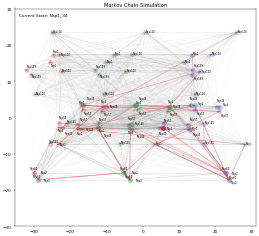

In [14]:
# Call the function (with parameters for animation length and speed)
anim, fig = visualize_graph_three_spokes_animated("data/transition_matrices/interactions-150-180-symmetric-100ns.pickle", 
                                                 title="Markov Chain Simulation", 
                                                 num_steps=100, 
                                                 interval=200)

# To display in a notebook
from IPython.display import HTML
HTML(anim.to_jshtml())

# To save animation to file
# anim.save('markov_chain_simulation.mp4', writer='ffmpeg')

/tmp/ipykernel_103536/668575865.py:180: RuntimeWarning: divide by zero encountered in log10
  if log_10: tm = np.log10(tm)
/tmp/ipykernel_103536/668575865.py:180: RuntimeWarning: divide by zero encountered in log10
  if log_10: tm = np.log10(tm)


/tmp/ipykernel_103536/668575865.py:180: RuntimeWarning: divide by zero encountered in log10
  if log_10: tm = np.log10(tm)


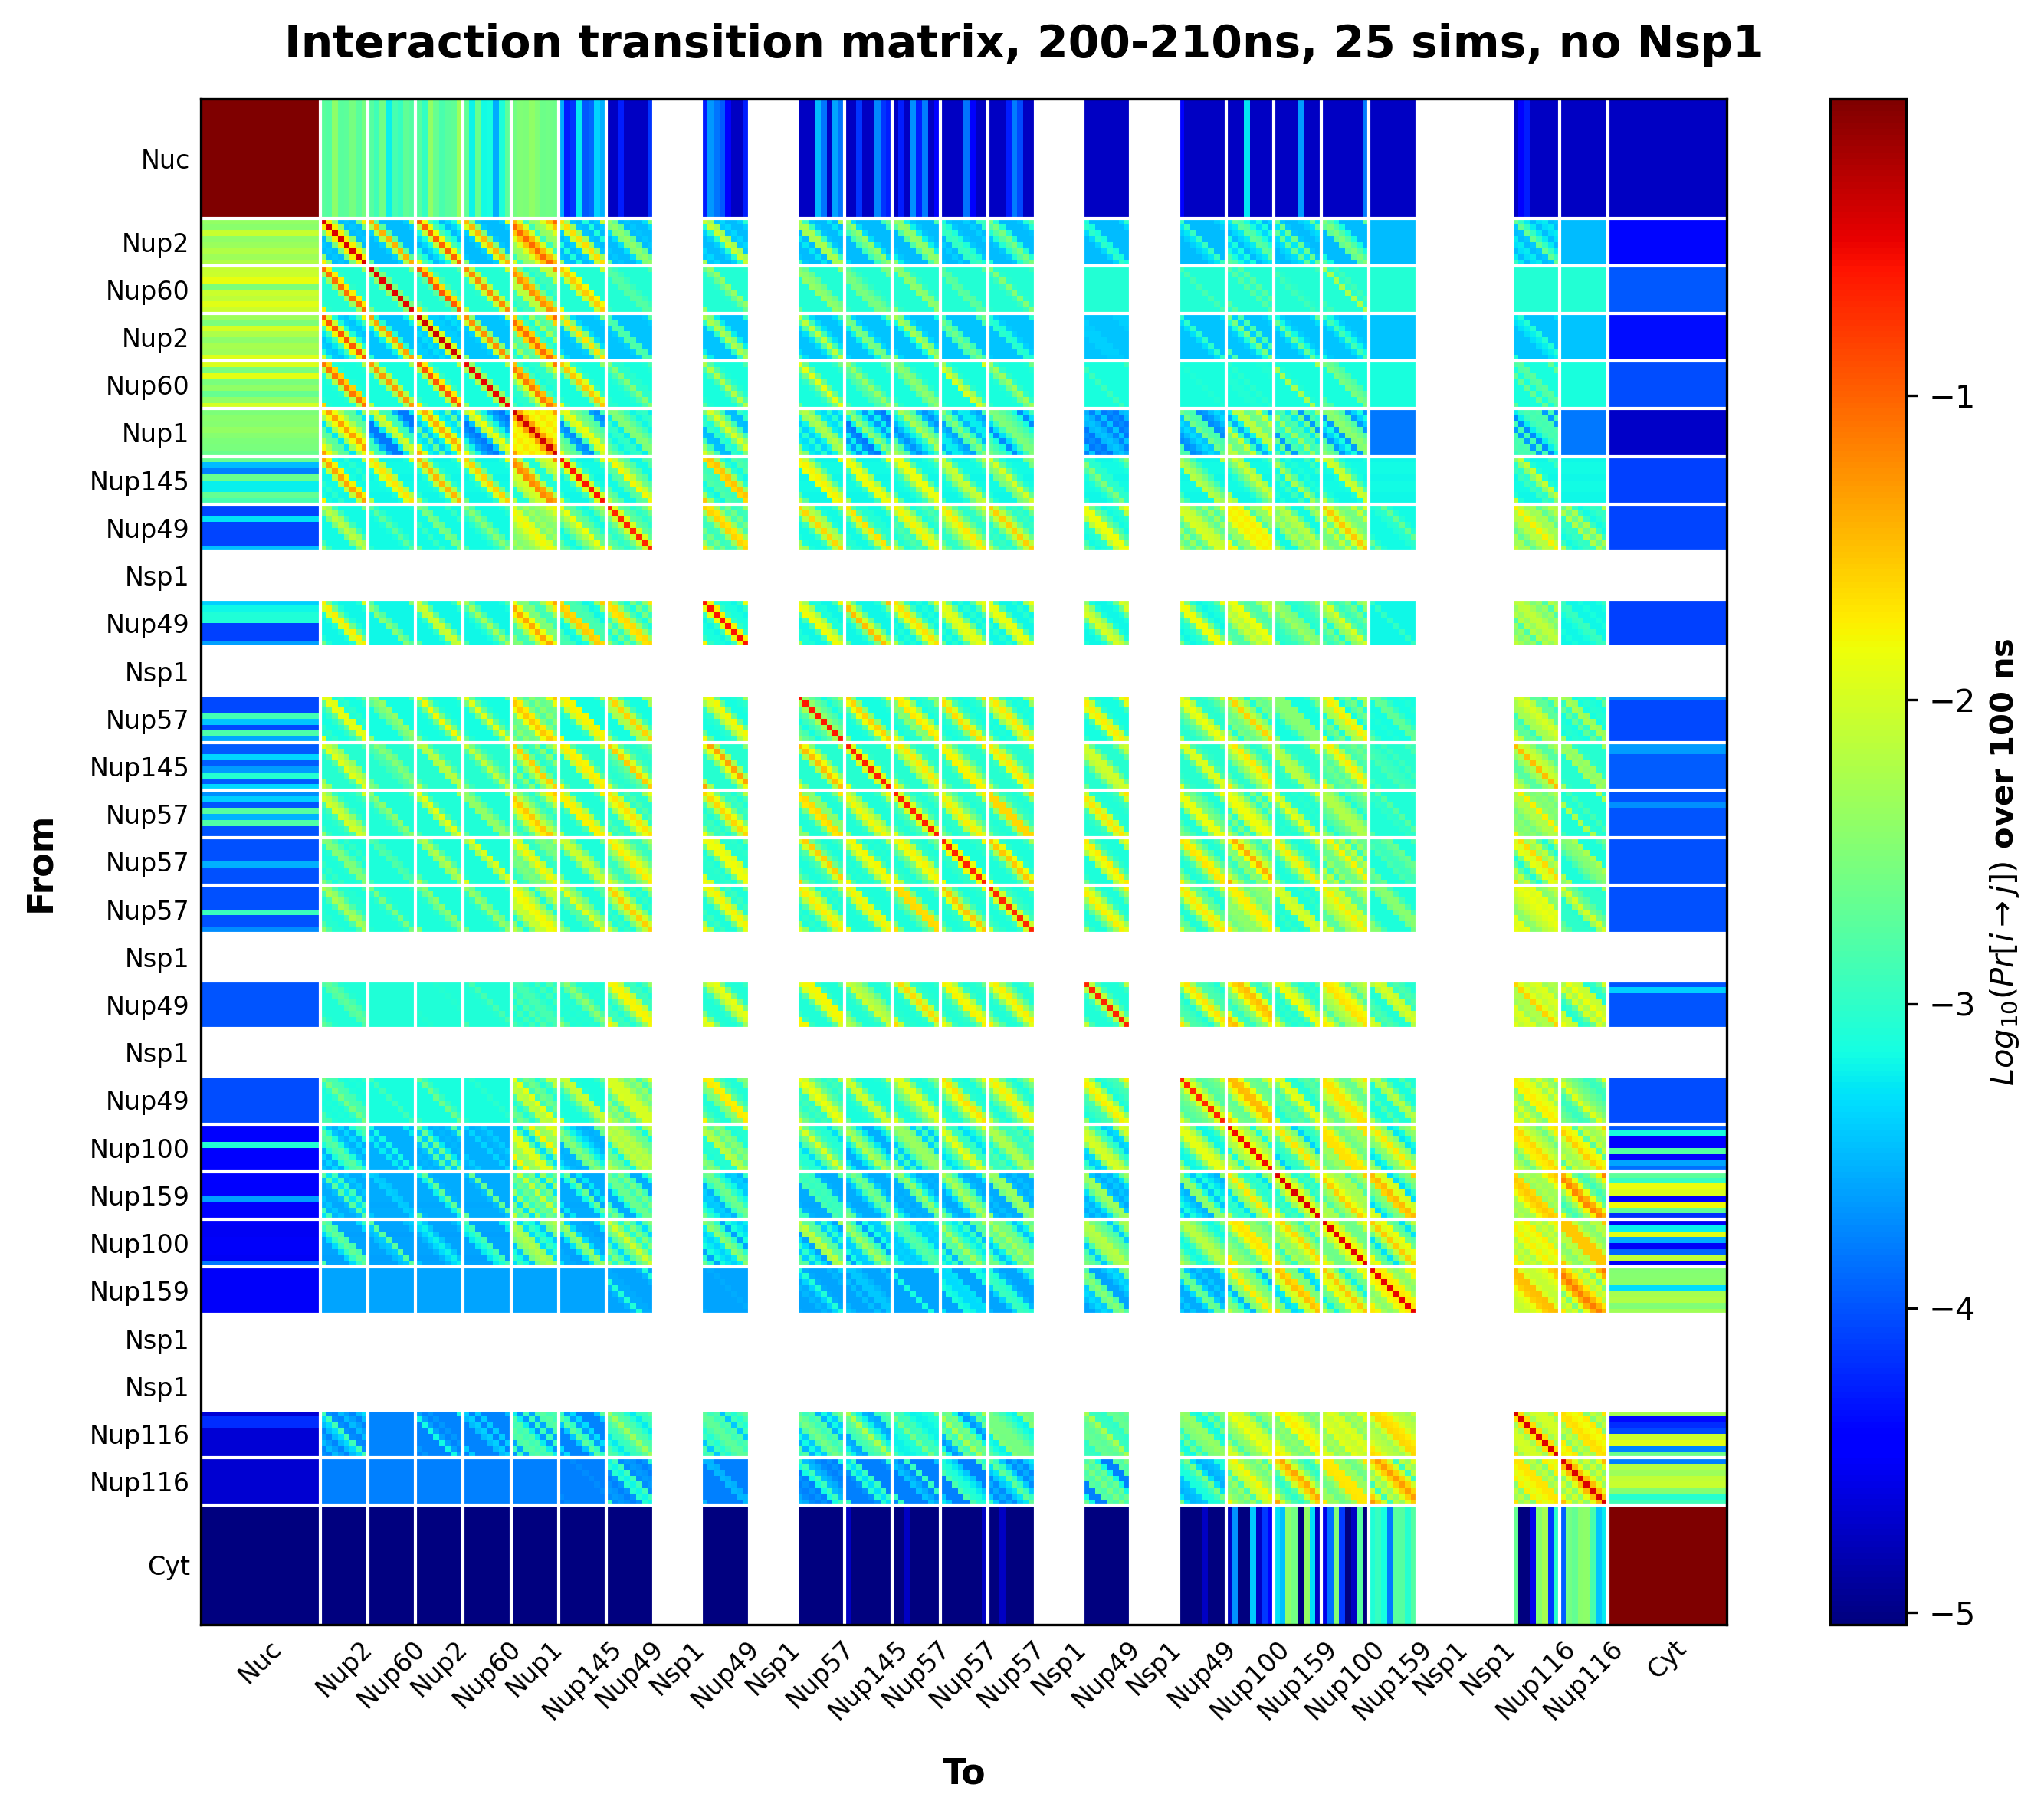

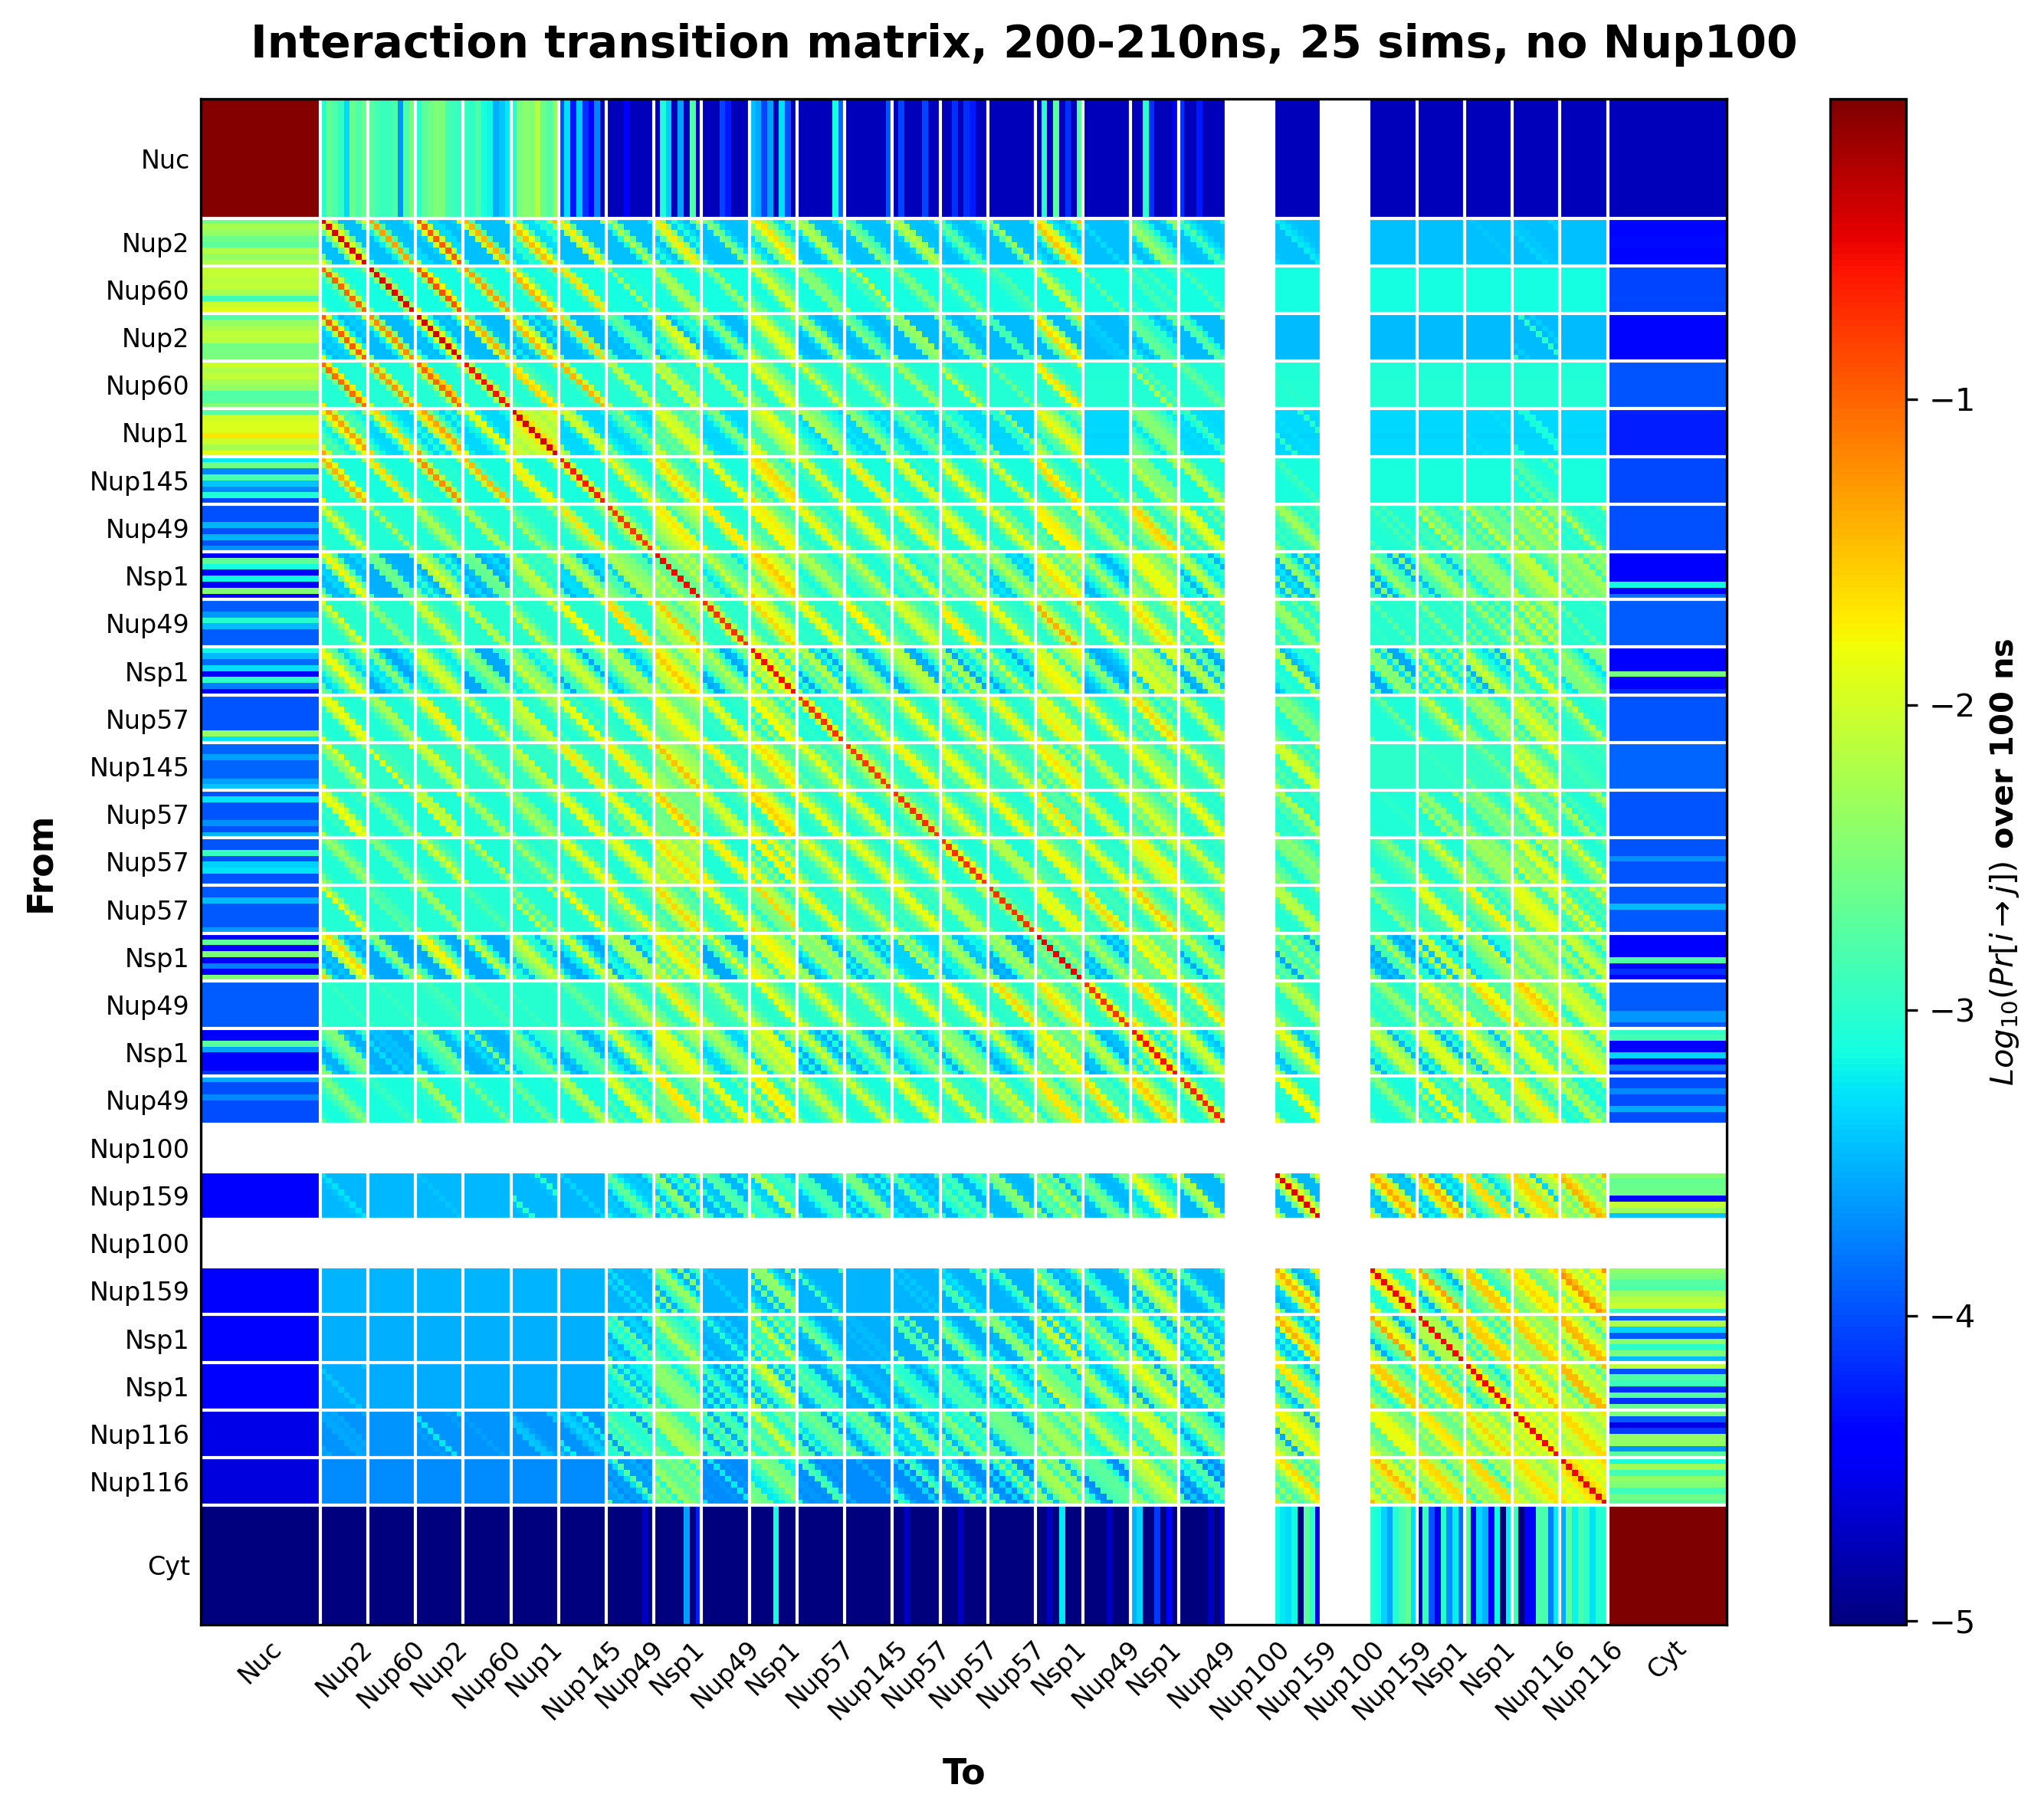

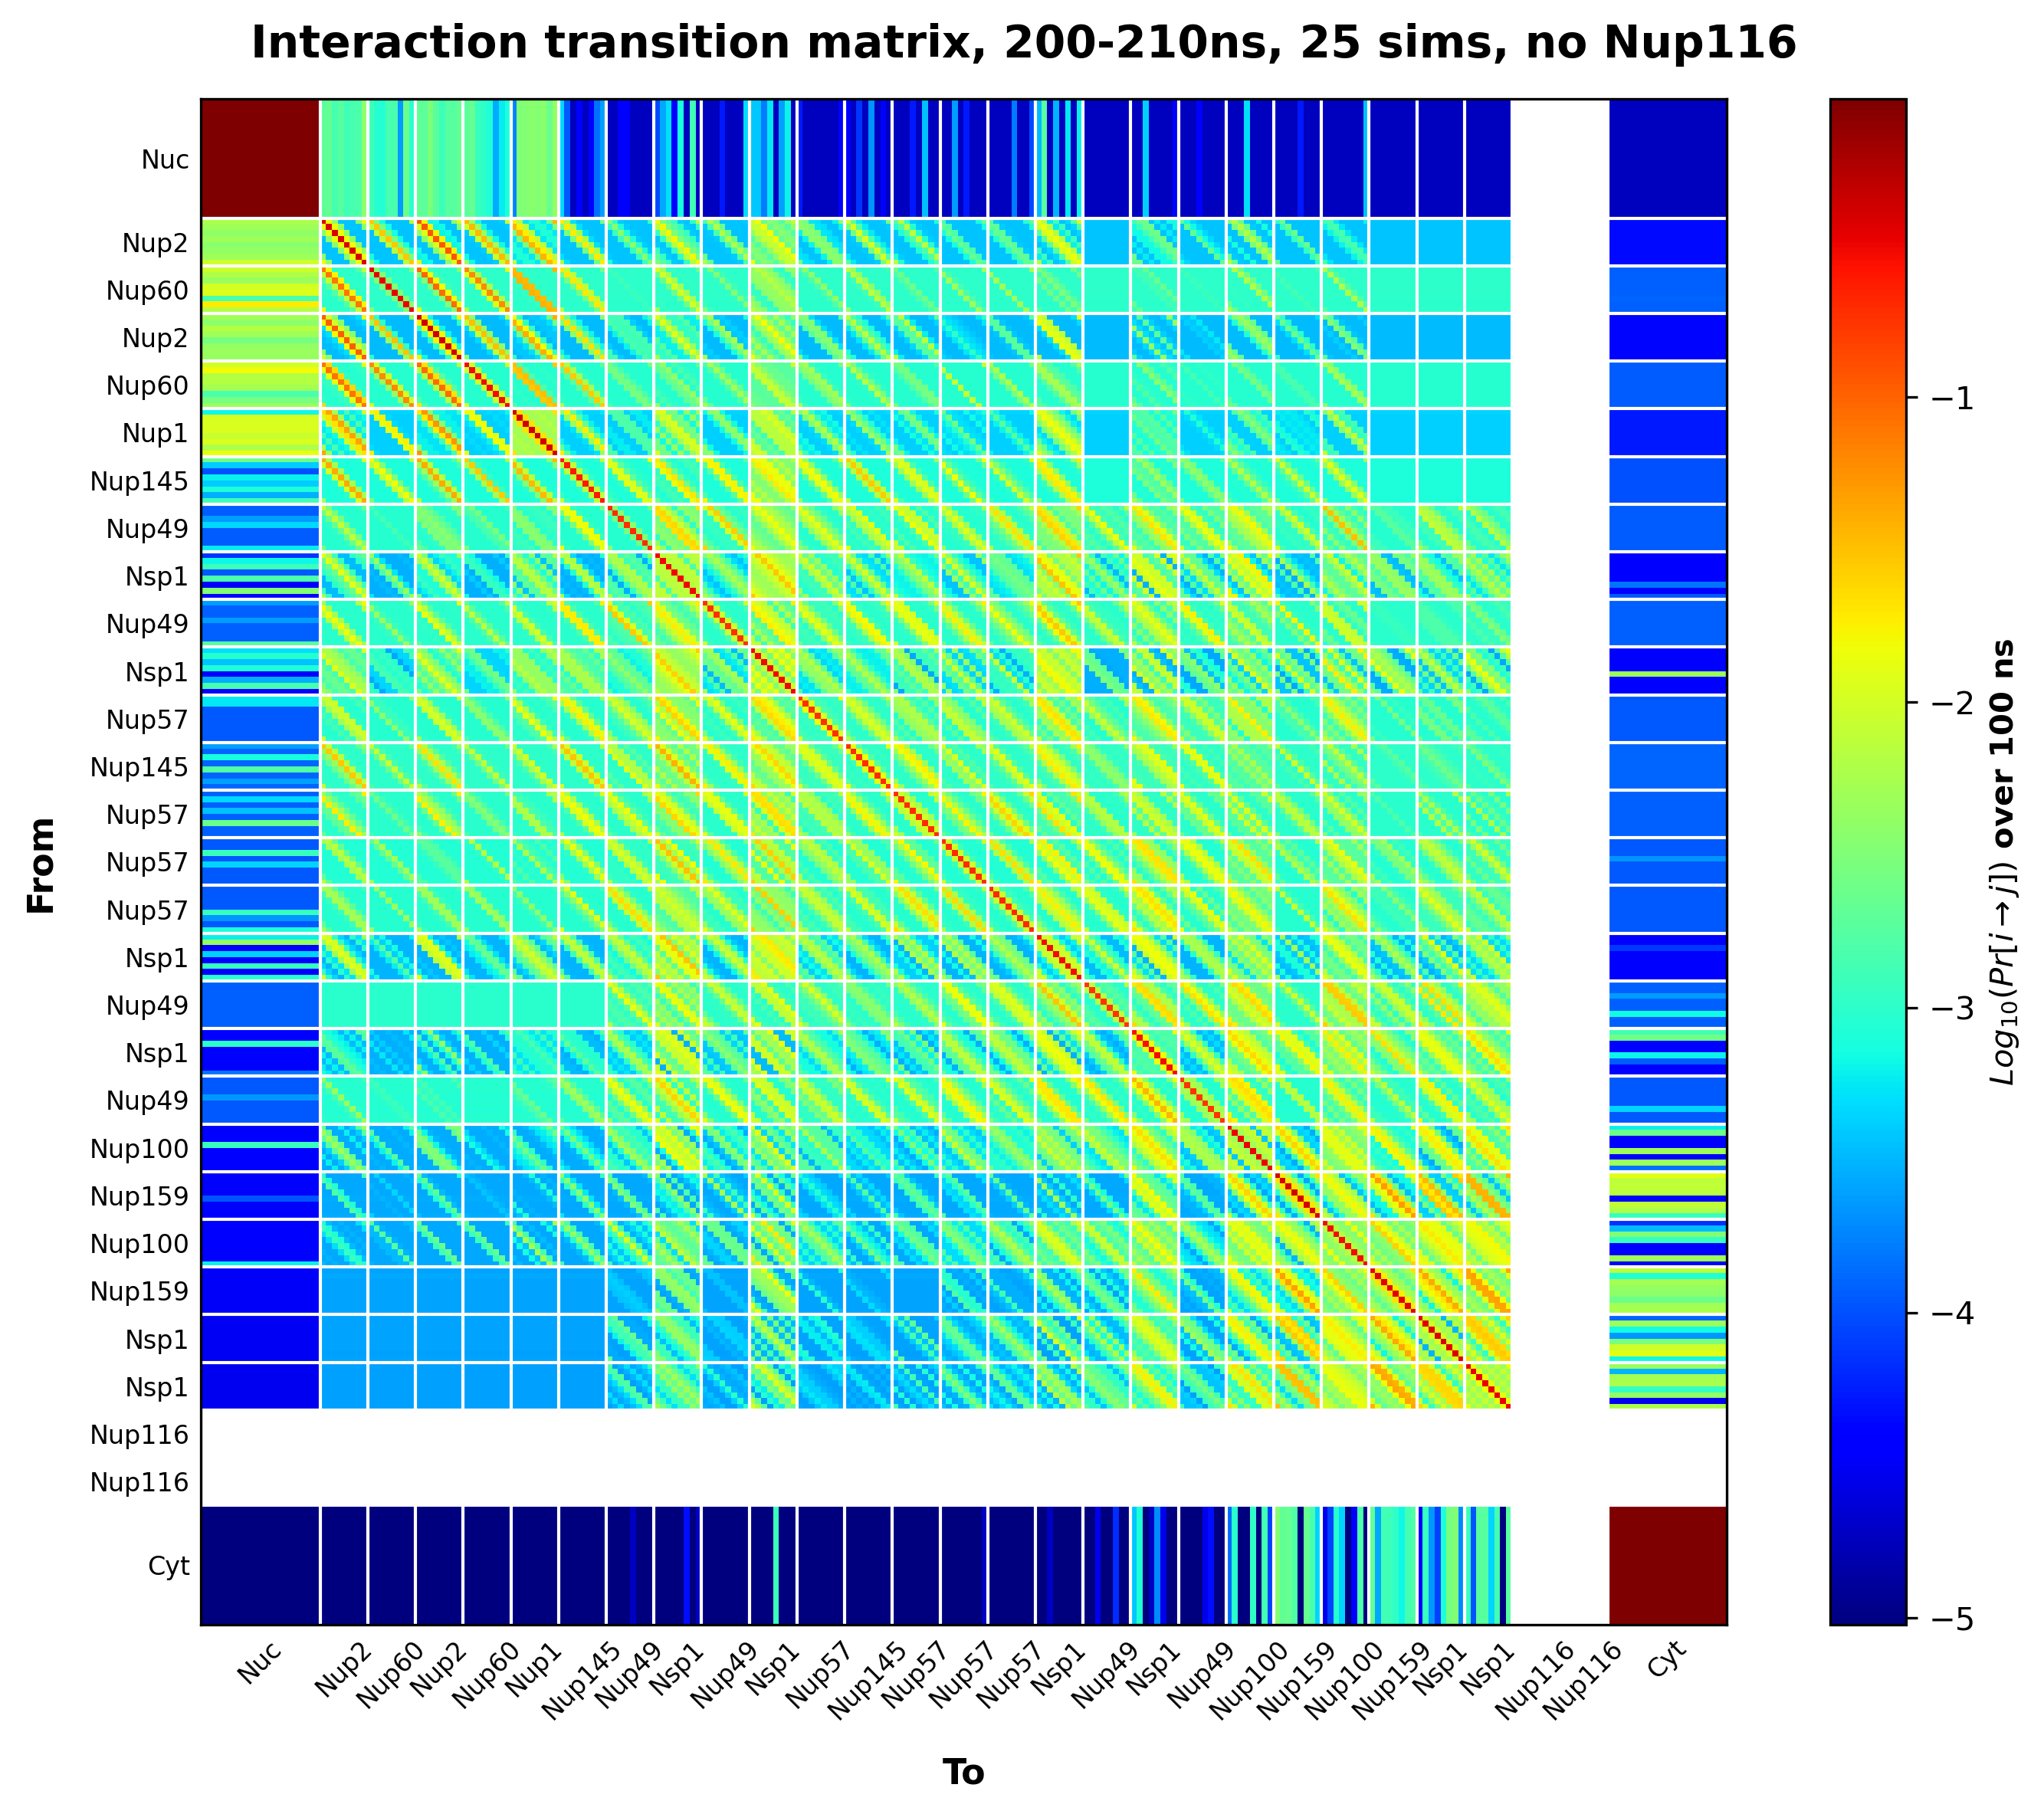

In [26]:
# visualize mutations heatmaps
for mutation in ["Nsp1", "Nup100", "Nup116"]:
    load_and_visualize_heatmap(f"data/mutations/no-{mutation.lower()}/transition_matrices/interactions-200-210-symmetric-100ns.pickle",
                               suptitle=f"Interaction transition matrix, 200-210ns, 25 sims, no {mutation}",
                               cbar_label=r'$Log_{10} (Pr[i \to j])$ over 100 ns',
                               log_10=True,
                               remove_fgs=[mutation])

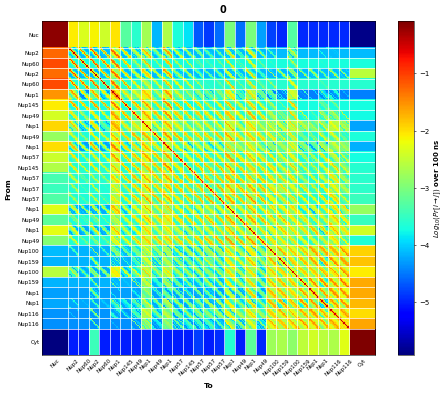

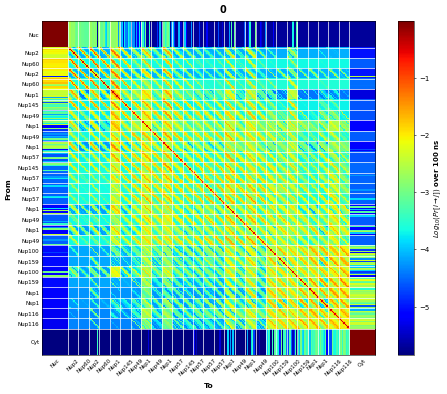

In [ ]:
for i in [0]: #, 1, 2, 4, 8, 16, 32, 64]:
    tm1 = load_and_visualize_heatmap(f"/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactions-150-180-sym-diag+{i}.pickle",
                               suptitle=f"{i}",
                               cbar_label=r'$Log_{10} (Pr[i \to j])$ over 100 ns',
                               log_10=True,
                               dpi=50)
    tm2 = load_and_visualize_heatmap("data/transition_matrices/interactions-150-180-symmetric-100ns.pickle",
                               suptitle=f"{i}",
                               cbar_label=r'$Log_{10} (Pr[i \to j])$ over 100 ns',
                               log_10=True,
                               dpi=50)